In [1]:
# Import jax
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
from jax import vmap

# Import tensorflow.distributions
import tensorflow_probability.substrates.jax as tfp
tfd = tfp.distributions
tfb = tfp.bijectors

# Import other packages
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from sdeint import itoEuler

# Imports from gpSLDS
from gpslds.likelihoods import Gaussian
from gpslds.em import fit_variational_em
from gpslds.transition import SparseGP
from gpslds.initialization import initialize_zs, initialize_affine_params
from gpslds.kernels import Linear, TimeDepSSL
from gpslds.quadrature import GaussHermiteQuadrature

#### Generating Time-dependent Data

In [2]:
# Create a grid of space-time points
xlim = 5
tlim = 5
N = 25

x_grid = jnp.linspace(-xlim, xlim, N)
X1, X2 = jnp.meshgrid(x_grid, x_grid)
X1, X2 = X1.ravel(), X2.ravel()
Xs = jnp.column_stack([X1, X2])
Ts = jnp.linspace(0, tlim, 10)

/var/folders/yh/8vstwtgd7rx8vmbgtpn324p00000gn/T/ipykernel_38753/722125764.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


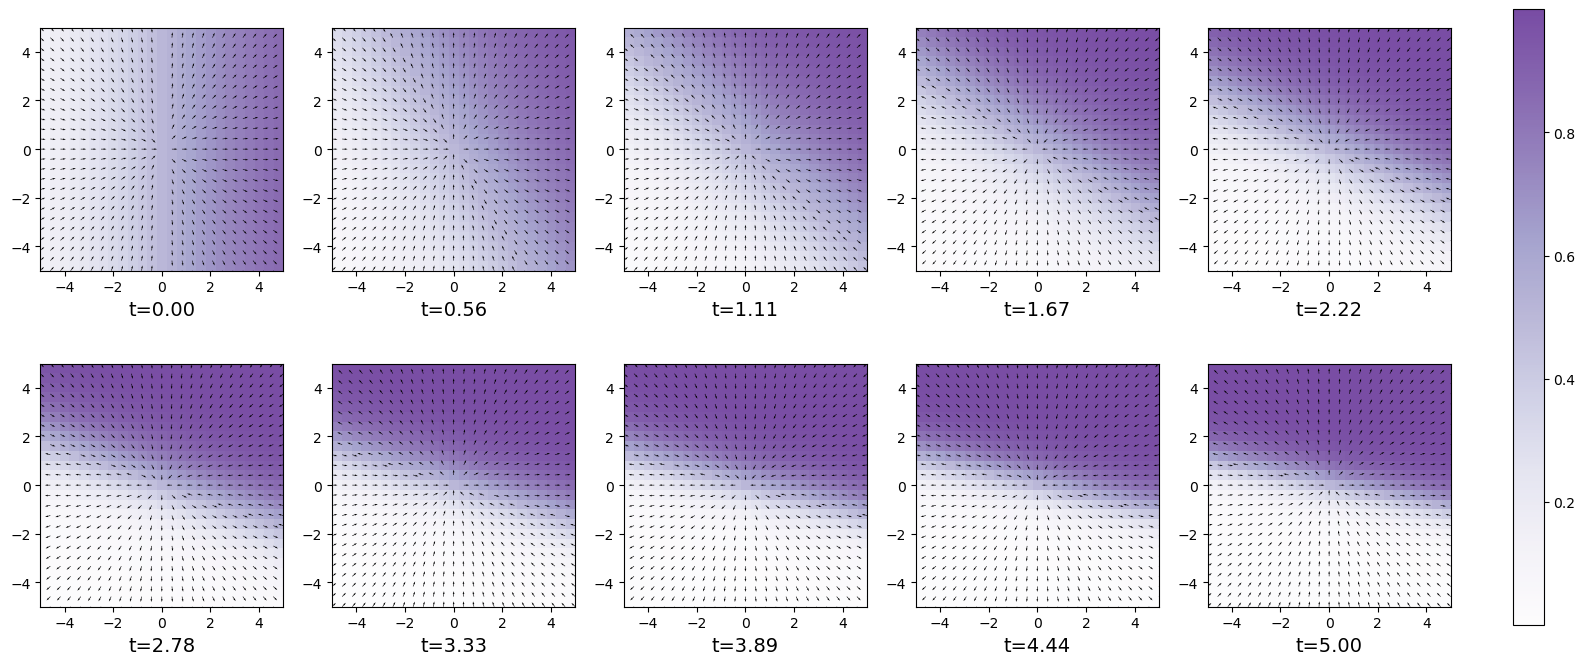

In [3]:
# Visualize some synthetic time-dependent dynamics
def linear_basis(x, t):
  """
  A linear basis of space-time
  """
  x = x.reshape(-1)
  t = t.reshape(-1)
  return jnp.array([jnp.array([1]), t, jnp.array([x[0]]), jnp.array([x[1]]),
                    t*x[0], t*x[1]])

def compute_multinomials_probs(W, basis, log_tau):
  activations = W.T @ basis
  pi = tfb.SoftmaxCentered().forward(activations / jnp.exp(log_tau))
  return pi


W = jnp.array([[0, 0, 1, 0, 0, 1]]).T

## TODO: Modify the flow field
def true_f(x, t):
  """
  True dynamics function, a linear combination of two linear dynamical systems
  """
  g = linear_basis(x, t)
  pi = compute_multinomials_probs(W, linear_basis(x, t), 1).flatten()

  diag = jnp.sin((2 * jnp.pi / 2.5) * t) + jnp.cos((2 * jnp.pi / 5) * t)
  return (pi[0] * jnp.array([[diag, 0], [0, diag]]) + pi[1] *
   jnp.array([[(-1)*diag, 0], [0,(-1)*diag]]) ) @  x.T


f = vmap(lambda t: vmap(lambda x: true_f(x, t))(Xs))(Ts)
probs = vmap(lambda t: vmap(lambda x: compute_multinomials_probs(W, linear_basis(x, t), 1).flatten())(Xs))(Ts)

global_min = jnp.min(probs)
global_max = jnp.max(probs)

fig, axs = plt.subplots(2, 5, figsize=(20,8))
for i, ax in enumerate(axs.ravel()):
    magnitude = jnp.sqrt(f[i,:,0]**2 + f[i,:,1]**2)

    ax.quiver(X1, X2, f[i,:,0] / magnitude, f[i,:,1] / magnitude, angles='xy')
    im = ax.imshow(probs[i, :, 0].reshape(N, N),
              origin='lower', cmap='Purples', alpha=0.7,
              vmin=global_min, vmax=global_max,
              extent=[X1.min(), X1.max(), X2.min(), X2.max()]
              )

    ax.set_aspect(1.)
    ax.set_xlim(-xlim, xlim)
    ax.set_ylim(-xlim, xlim)
    ax.set_xlabel(f"t={Ts[i]:.2f}", fontsize=14)

cbar = fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.05, pad=0.04)
fig.show()

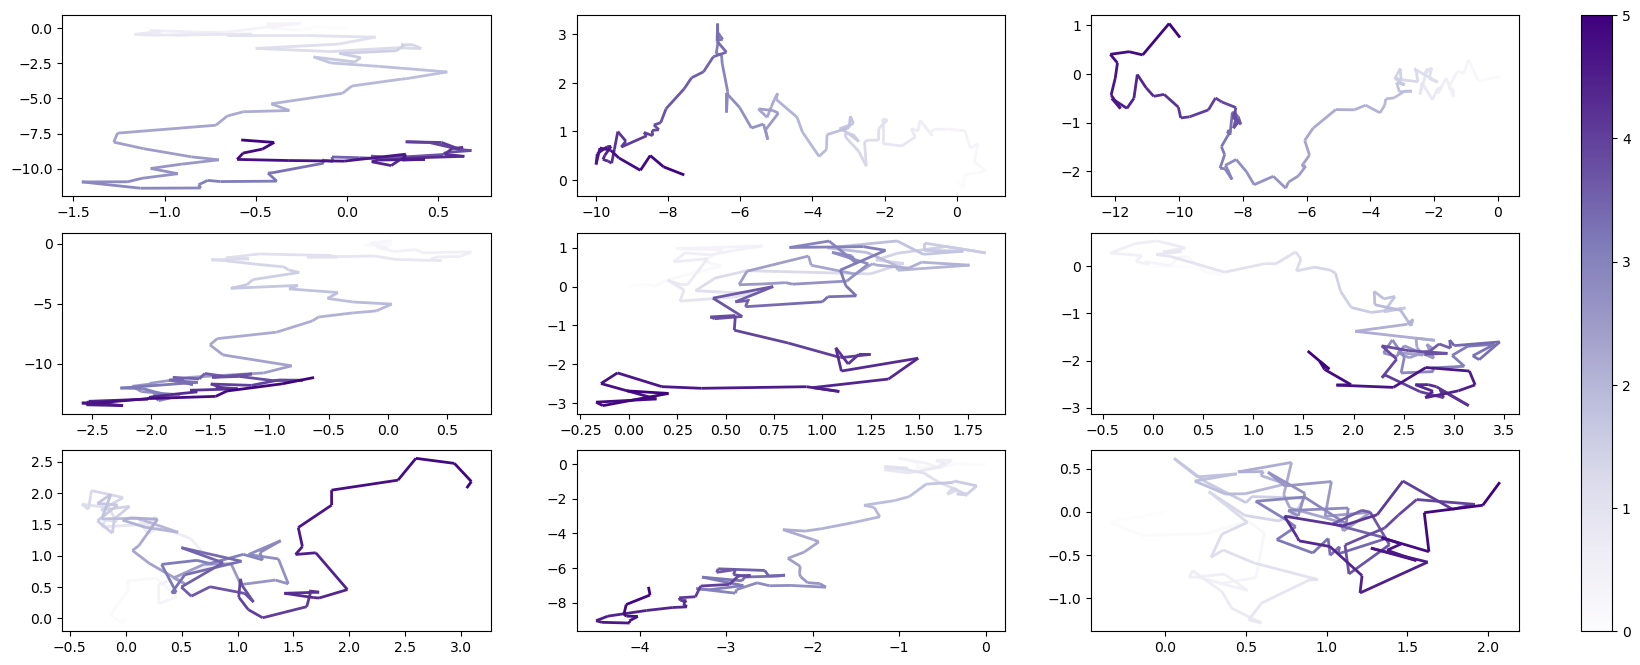

In [4]:
# Now, visualize samples from these dynamics
T = 100
t_grid = jnp.linspace(0, tlim, T)

true_G = lambda x, t: jnp.identity(2)

fig, axs = plt.subplots(3, 3, figsize=(20,8))

# Create the colormap and normalizer
cmap = matplotlib.colormaps['Purples']
norm = plt.Normalize(t_grid.min(), t_grid.max())

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(t_grid)

# TODO: change initial condition of latent dynamics
for i, ax in enumerate(axs.ravel()):

    # Sample latent dynamics
    x = itoEuler(true_f, true_G, jnp.array([0, 0]), t_grid)

    points = jnp.array([x[:, 0], x[:, 1]]).T.reshape(-1, 1, 2)
    segments = jnp.concatenate([points[:-1], points[1:]], axis=1)

    lc = LineCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(t_grid) 
    lc.set_linewidth(2)

    ax.add_collection(lc)
    ax.autoscale()

# Add a colorbar to show the mapping of t_grid to colors
fig.colorbar(sm, ax=axs, orientation='vertical', fraction=0.02, pad=0.04)

plt.show()

#### Instantiating the Time-dependent gpSLDS Model

In [5]:
# Generate emission matrices (at random)
output_dim = 10
latent_dim = 2

key = jr.PRNGKey(1)
key_C, key_d = jr.split(key, 2)

# True emission matrices C,d
C = jr.uniform(key_C, (output_dim,2))
d = jr.uniform(key_d, (output_dim,1))

n_trials = 1
ys_binned = jnp.zeros((n_trials, t_grid.shape[0], output_dim))
xs_true = jnp.zeros((n_trials, t_grid.shape[0], latent_dim))

key = jr.PRNGKey(2)
output_dist_keys= jr.split(key, n_trials)
key = jr.PRNGKey(3)
init_cond_keys = jr.split(key, n_trials)
for i in range(n_trials):
    # Initial condition is m_0 = 0, S_0 = I
    x0 = tfd.Normal(loc = 0, scale=1).sample((2,), seed=init_cond_keys[i])
    xs_true = xs_true.at[i, :, :].set(itoEuler(true_f, true_G, x0, t_grid))
    y = tfd.Normal(loc= x @ C.T + d.T, scale=jnp.ones((ys_binned.shape[1], ys_binned.shape[2]))).sample(seed=output_dist_keys[i])
    ys_binned = ys_binned.at[i,:,:].set(y)

# All timesteps are observed
t_mask = jnp.ones((n_trials, t_grid.shape[0]))
trial_mask = jnp.ones((n_trials, t_grid.shape[0]))

In [6]:
# Initialize the likelihood object
likelihood = Gaussian(ys_binned, t_mask)

# Instantiate C and d using PCA (since we have Gaussian likelihood)
C_init, d_init = initialize_affine_params(latent_dim, ys_binned)
output_params_init = {'C': C_init, 'd': d_init, 'R': jnp.ones((output_dim))}

x0_init_params = jnp.stack([jnp.zeros((latent_dim,)) for i in range(n_trials)]) # (n_trial, K)

In [7]:
# Instantiate grid of inducing points 
zs_x = initialize_zs(latent_dim, zs_lim=xlim, num_per_dim=5)
zs_t = jnp.linspace(0, 5, 20).reshape((-1, 1))

# Basis is (1, t, x1, x2, tx1, tx2)
num_bases = 6
basis_set = lambda z: jnp.array([1., z[2], z[0], z[1], z[2] * z[0], z[2] * z[1]])

# Sanity check
z1, z2 = jnp.array([1, 2, 3]), jnp.array([4, 5, 6])
print(basis_set(z1))

gh_quad = GaussHermiteQuadrature(latent_dim, n_quad=6)

# Instantiate the time-dependent kernel object as well as the GP
linear_kernel = Linear(gh_quad)
kernel = TimeDepSSL(gh_quad, linear_kernel, basis_set=basis_set)
fn = SparseGP(zs_x, kernel, zs_t=zs_t)


[1. 3. 1. 2. 3. 6.]


In [8]:
linear_kernel = Linear(gh_quad)
kernel = TimeDepSSL(gh_quad, linear_kernel, basis_set=basis_set)
fn = SparseGP(zs_x, kernel, zs_t=zs_t)

In [9]:
# Instantiate kernel parameters
num_states = 2
key = jr.PRNGKey(4)
key_W, key_fp = jr.split(key, 2)
W_init = tfd.Normal(0, 1).sample((num_bases, num_states-1), seed=key_W).astype(jnp.float64)
fp_init = tfd.Normal(0, 1).sample((num_states, latent_dim), seed=key_fp).astype(jnp.float64)
tau_init = 0.5
kernel_params_init = {
    "linear_params": [{"fixed_point": fp_init[i]} for i in range(num_states)],
    "log_tau": jnp.log(tau_init),
    "W": W_init
}

# Demonstrate that we can evaluate the time-dependent kernel
print(round(kernel.K(z1, z2, kernel_params=kernel_params_init), 2))


24.91


In [10]:
# Sanity check that kernel produces expected output

## x components of input vectors
x1, x2 = z1[0:2,], z2[0:2,]

linear_params = kernel_params_init['linear_params']
log_tau = kernel_params_init['log_tau']

## compute weightings of the different linear components
pi_w1 = tfb.SoftmaxCentered().forward(kernel_params_init['W'].T @ basis_set(z1) / jnp.exp(log_tau))
pi_w2 = tfb.SoftmaxCentered().forward(kernel_params_init['W'].T @ basis_set(z2) / jnp.exp(log_tau))

linear_kernels = jnp.array([linear_kernel.K(x1, x2, param) for param in linear_params]) # (num_states,)
print(round((pi_w1 * pi_w2 * linear_kernels).sum(),2))

24.91


#### Fitting the time-dependent gpSLDS model

In [ ]:
# Key for minibatching
key = jr.PRNGKey(5)

# Set number of total vEM iters
n_iters = 1

# Set a learning rate schedule
decay, forgetting_rate = 50, -0.9
learning_rates = (decay + jnp.arange(1, 1 + n_iters)) ** (forgetting_rate)

# Fit the model
result = fit_variational_em(key,
                            latent_dim,
                            t_grid, # Notice now, we pass the entire time grid to the variational EM algo (as opposed to just dt)
                            fn, # sparse GP model
                            likelihood,
                            trial_mask,
                            output_params_init,
                            kernel,
                            kernel_params_init,
                            inputs=None,
                            m0=x0_init_params,
                            mu0=x0_init_params,
                            n_iters=n_iters,
                            n_iters_e=5,
                            n_iters_m=5,
                            learning_rates=learning_rates,
                            batch_size=n_trials)

# Collect results
ms, Ss, As, bs, B, q_u_mu, q_u_sigma, output_params, kernel_params, elbos = result